# Prompt design case study — three wordings of the same AI-researcher prompt

The same two-track figure as
[two_track_figure.ipynb](two_track_figure.ipynb), over the prompt-design runs:
rows are prompt variants rather than ablations, and each is measured against the
original AI-researcher prompt in the strip on top. `*` marks significance at 95%
(corpus-level paired bootstrap, n=100,000).

Pairwise only — these runs have no pointwise data, and both tracks are the plan
form of the idea, which is what the AI-researcher prompt was written for.

Reads the `unified_*.json` chart data `merge_ablation_runs.py` writes; writes a
PDF (vector, for the paper) and a PNG to `output/figures/prompt-design/`. The
drawing is `common.TwoTrackFigure` — this notebook is only the wording.

In [6]:
import sys
from pathlib import Path

from IPython.display import Image, display

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "src").is_dir() and (p / "output").is_dir())
sys.path.insert(0, str(ROOT / "src"))

from novelty_eval.figures.common import TwoTrackFigure

print(ROOT)

/Users/noysternlicht/myCode/novelty-eval


## What the figure says

Everything that decides what this figure says is in the next cell. The two
tracks are separate merges, so a variant's row is the same wording scored
against a different baseline on each side.

In [7]:
FIG = TwoTrackFigure(
    root=ROOT,
    figure="prompt-design",           # output subdirectory and filename prefix
    # (block title, merge dir under output/ablation_sweeps, name token)
    tracks=[("Human-only", "merge_ai_researcher_hvh-plan", "human"),
            ("Human + generated", "merge_ai_researcher_vanilla_ai-plan", "vanilla")],
    # (panel name, row label), top to bottom
    rows=[("ai_researcher_no_review", "No review mention"),
          ("ai_researcher_comparative", "Comparative language")],
    # judge columns, left to right
    models=["claude-opus-4-6", "gpt-5.4"],
    metrics={"pairwise": "pairwise_accuracy_strict"},
    row_axis_label="Prompt variant",
    # The strip is not an ablated baseline here: it is the prompt as published.
    baseline_label="Original prompt",
    # The key to the marked cells, set small in the bottom margin beside the
    # column title. Only the delta figure marks anything; "" drops the key.
    sig_note="* significant at 95% (bootstrap)",
)

## The numbers

`FIG.table(setup)` is the whole data path: one tidy row per (track, ablation,
judge), everything already in points. Print it, sort it, `.query()` it — if a
cell in the figure looks wrong, the reason is visible here, before any drawing
happens.

A missing panel, or a cell `common.UNSUPPORTED_CELLS` blanks (a judge that
cannot honour the ablation), gives `NaN` and draws as `—`.

In [8]:
print(FIG.table(next(iter(FIG.metrics))).to_string())

               track              ablation     judge  baseline  ablated  delta  significant
0         Human-only     No review mention  opus-4-6     74.03    61.04 -12.99         True
1         Human-only     No review mention   gpt-5.4     75.97    59.74 -16.23         True
2         Human-only  Comparative language  opus-4-6     74.03    74.68   0.65        False
3         Human-only  Comparative language   gpt-5.4     75.97    75.32  -0.65        False
4  Human + generated     No review mention  opus-4-6     96.10    50.65 -45.45         True
5  Human + generated     No review mention   gpt-5.4     85.06    16.88 -68.18         True
6  Human + generated  Comparative language  opus-4-6     96.10    63.64 -32.46         True
7  Human + generated  Comparative language   gpt-5.4     85.06    58.44 -26.62         True


## The figure: what each change did

One `pcolormesh` per track, then the cell text on top of it. Diverging red→green
scale centred on zero and shared across both blocks, so a colour means the same
thing left and right; every cell also prints its number, so colour is never the
only encoding. The baseline strip is drawn outside the grid, in a shade of its
own, so it never reads as a delta of zero.

output/figures/prompt-design/prompt-design_pairwise_filtered_pairwise_accuracy_strict.png (+ .pdf)


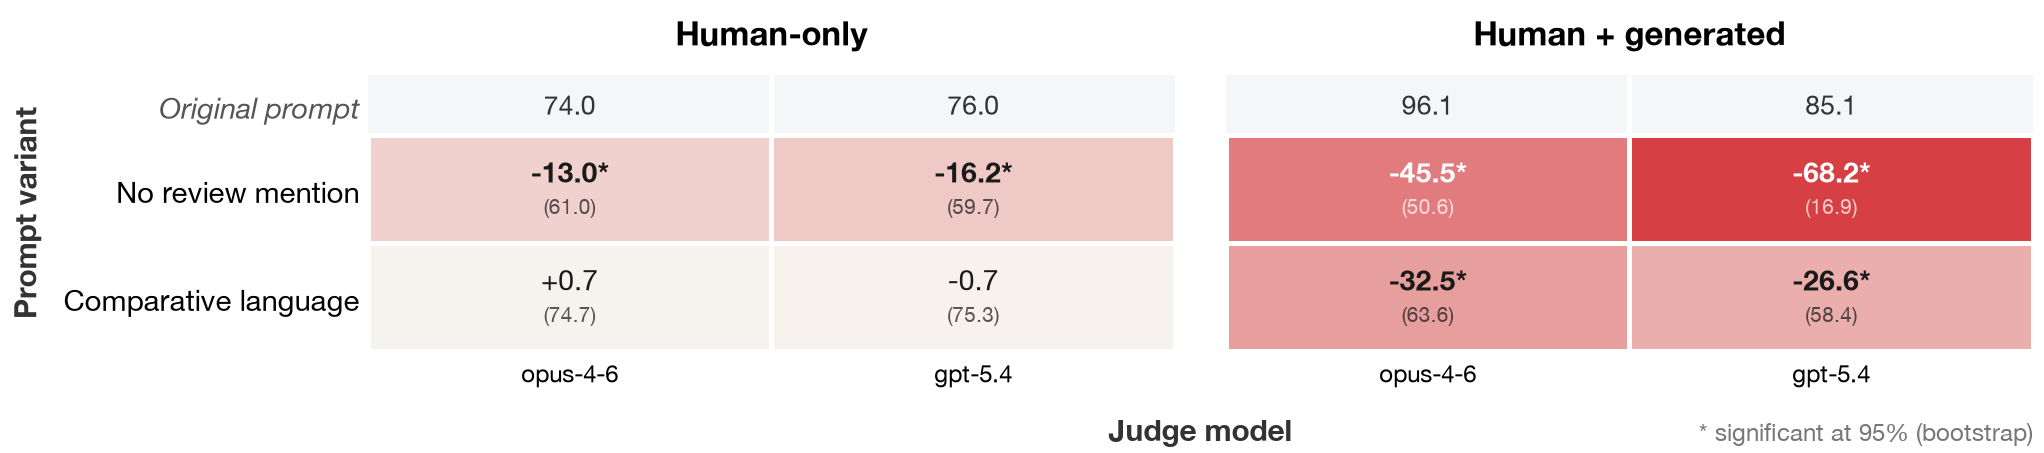

In [9]:
for setup in FIG.metrics:
    png = FIG.draw(setup)
    print(png.relative_to(ROOT), "(+ .pdf)")
    display(Image(filename=str(png)))